## Investigating the margins of linear classifiers

In this example, we'll look at the margins of a few different linear classifiers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# plot cosmetics
%config InlineBackend.figure_format = 'svg' 
plt.style.use('bmh')
plt.rcParams['image.cmap'] = 'Paired_r'

We'll first generate some random synthetic data.

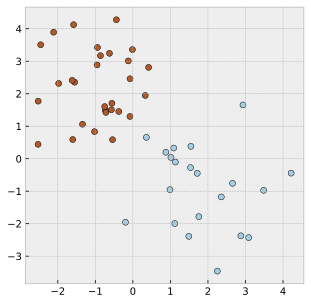

In [2]:
np.random.seed(4)

n = 50

# Generate +1 or -1 with uniform probability
Y = np.random.choice([-1, 1], size=n)

# Generate some 2-dimensional normally distributed data
X = np.random.normal(size=(n, 2))

# For each instance, depending on whether it's positive or negative,
# we shift it a bit. The idea is just to make sure that the dataset
# becomes two well-separated classes.
X[:,0] += 1.2 * Y + 0.3
X[:,1] += -1.6 * Y + 0.6

# Plot the data using a scatterplot.
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=Y, edgecolors='k');

We make a function `plot_separator` which plots the decision boundary defined by a classifier. Optionally, it can also draw lines corresponding to the margins.

The code is a bit kludgy, because we want to draw the margin lines. If you want to see how to draw the decision boundaries in a slighly neater way, please take a look at [this](https://scikit-learn.org/stable/auto_examples/svm/plot_iris_svc.html) and [this](https://scikit-learn.org/stable/auto_examples/tree/plot_iris_dtc.html) example from scikit-learn's official documentation.

In [3]:
def margin(X, Y, scores_X, boundary, pos):
    y = 1 if pos else -1
    scores_X = y*scores_X[Y==y]    
    min_ix = scores_X[scores_X>0].argmin()    
    min_score = scores_X[scores_X>0].min()
    min_instance = X[Y==y][scores_X>0][min_ix]
    dists = [ np.linalg.norm(min_instance - x) for x in boundary ]
    return min(dists), min_score
        
def contour(scores, c):
    tol = 1e-2
    return np.abs(scores - c) < tol

def plot_boundary(boundary, marker):
    boundary = boundary[boundary[:,0].argsort()]
    plt.plot(boundary[:,0], boundary[:,1], marker)
    
def plot_separator(X, Y, model, plot_margin=False):
    X0 = X[:,0]
    X1 = X[:,1]
    
    plt.figure(figsize=(5,5))
    plt.scatter(X0, X1, c=Y, edgecolors='k')
        
    x0_r = np.linspace(min(X0)-0.5, max(X0)+0.5, 500)
    x1_r = np.linspace(min(X1)-0.5, max(X1)+0.5, 500)
    
    pairs = []
    for x0 in x0_r:
        for x1 in x1_r:
            pairs.append([x0, x1])
    pairs = np.array(pairs)

    scores = model.decision_function(pairs)
    scores_X = model.decision_function(X)

    boundary = pairs[contour(scores, 0)]
    
    plot_boundary(boundary, 'k')
    
    if plot_margin:
        pm, pmin = margin(X, Y, scores_X, boundary, True)
        nm, nmin = margin(X, Y, scores_X, boundary, False)
    
        m = min(pmin, nmin)
    
        pb = pairs[contour(scores, m)]
        nb = pairs[contour(scores, -m)]
        
        plot_boundary(nb, 'k:')
        plot_boundary(pb, 'k:')
        
        plt.legend(['decision boundary', 
                    'margin = {:.2f}'.format(min(pm, nm))], bbox_to_anchor=(1.04,1), loc="upper left")
    

The *support vector classifier* (SVC) tries to find the line that gives us the highest margin.

Strictly speaking, scikit-learn's LinearSVC is a *soft-margin SVC*, which means that the classifier is allowed to "cheat" a bit and disregard outliers. If you set `C` to a high value, it becomes more like a hard-margin SVC, which means that it will work hard to find the best separation.

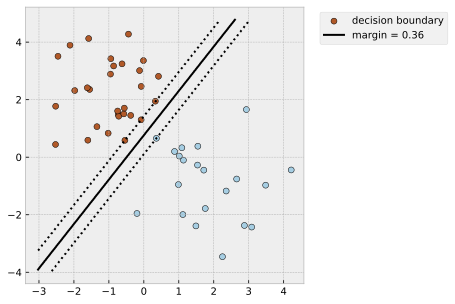

In [4]:
from sklearn.svm import LinearSVC

svc = LinearSVC(C=100, loss='hinge', dual='auto')
svc.fit(X, Y)
plot_separator(X, Y, svc, plot_margin=True)

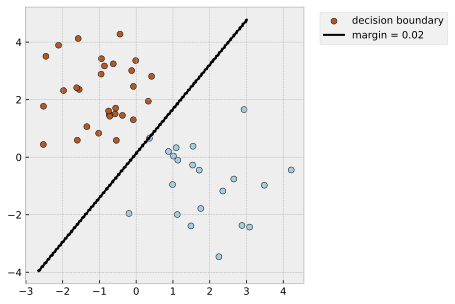

In [13]:
from sklearn.svm import LinearSVC

svc = LinearSVC(C=1, loss='hinge', dual='auto')
svc.fit(X, Y)
plot_separator(X, Y, svc, plot_margin=True)

The perceptron on the other hand does not care particularly about the margin. It will adjust the decision boundary until it finds a separation, and then it will terminate. As you see in this example, it might be the case that some instances are near the decision boundary. The result will depend on how the parameters of the model are initialized; if you change `random_state`, the line will end up somewhere else.

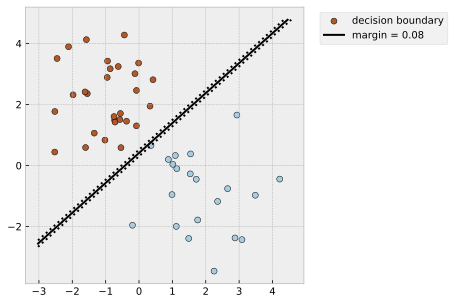

In [5]:
from sklearn.linear_model import Perceptron

perc = Perceptron(max_iter=10, random_state=0)
perc.fit(X, Y)
plot_separator(X, Y, perc, plot_margin=True)

The logistic regression model solves an optimization problem that is quite similar to the SVC, which will also result in a fairly large margin.

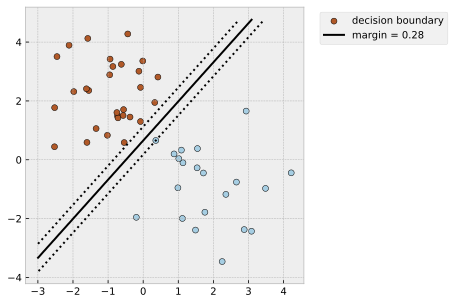

In [6]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=100)
lr.fit(X, Y)
plot_separator(X, Y, lr, plot_margin=True)